In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [4]:
df = pd.read_csv(r"C:\Users\aadam\Desktop\Algorithmic Trading\Gold_Prediction\gold_price_data.csv")
df['Date'] = pd.to_datetime(df['Date']); df = df.sort_values('Date').reset_index(drop=True)
print('Shape:', df.shape)
df.head()

Shape: (2290, 6)


,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (2290, 6)

Dtypes:
float64           5
datetime64[ns]    1
Name: count, dtype: int64


In [6]:
df.describe(include='all').T.head(20)

,count,mean,min,25%,50%,75%,max,std
Date,2290,2013-03-17 08:23:41.135371008,2008-01-02 00:00:00,2010-08-20 00:00:00,2013-03-13 12:00:00,2015-10-25 00:00:00,2018-05-16 00:00:00,NaN
SPX,2290.0,1654.315776,676.530029,1239.874969,1551.434998,2073.01007,2872.870117,519.11154
GLD,2290.0,122.732875,70.0,109.725,120.580002,132.840004,184.589996,23.283346
USO,2290.0,31.842221,7.96,14.38,33.869999,37.827501,117.480003,19.523517
SLV,2290.0,20.084997,8.85,15.57,17.2685,22.8825,47.259998,7.092566
EUR/USD,2290.0,1.283653,1.039047,1.171313,1.303297,1.369971,1.598798,0.131547


In [7]:
print('Duplicates:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 0
Memory (MB): 0.1


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No missing values')

No missing values


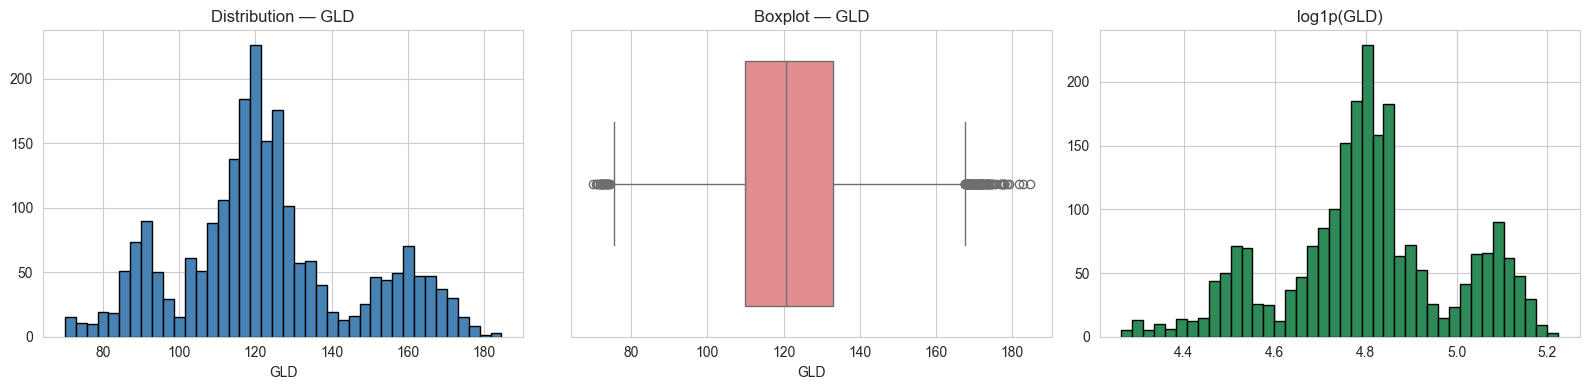

Skewness : 0.334
Kurtosis : -0.275
count    2290.00
mean      122.73
std        23.28
min        70.00
25%       109.73
50%       120.58
75%       132.84
max       184.59
Name: GLD, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['GLD'].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution — GLD')
axes[0].set_xlabel('GLD')
sns.boxplot(x=df['GLD'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — GLD')
# Log scale (skewed targets)
axes[2].hist(np.log1p(df['GLD'].dropna()), bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('log1p(GLD)')
plt.tight_layout(); plt.show()
print('Skewness :', round(df['GLD'].skew(), 3))
print('Kurtosis :', round(df['GLD'].kurtosis(), 3))
print(df['GLD'].describe().round(2))

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'GLD' in numeric_cols:
    numeric_cols.remove('GLD')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols[:30])

Numeric features (4):
['SPX', 'USO', 'SLV', 'EUR/USD']


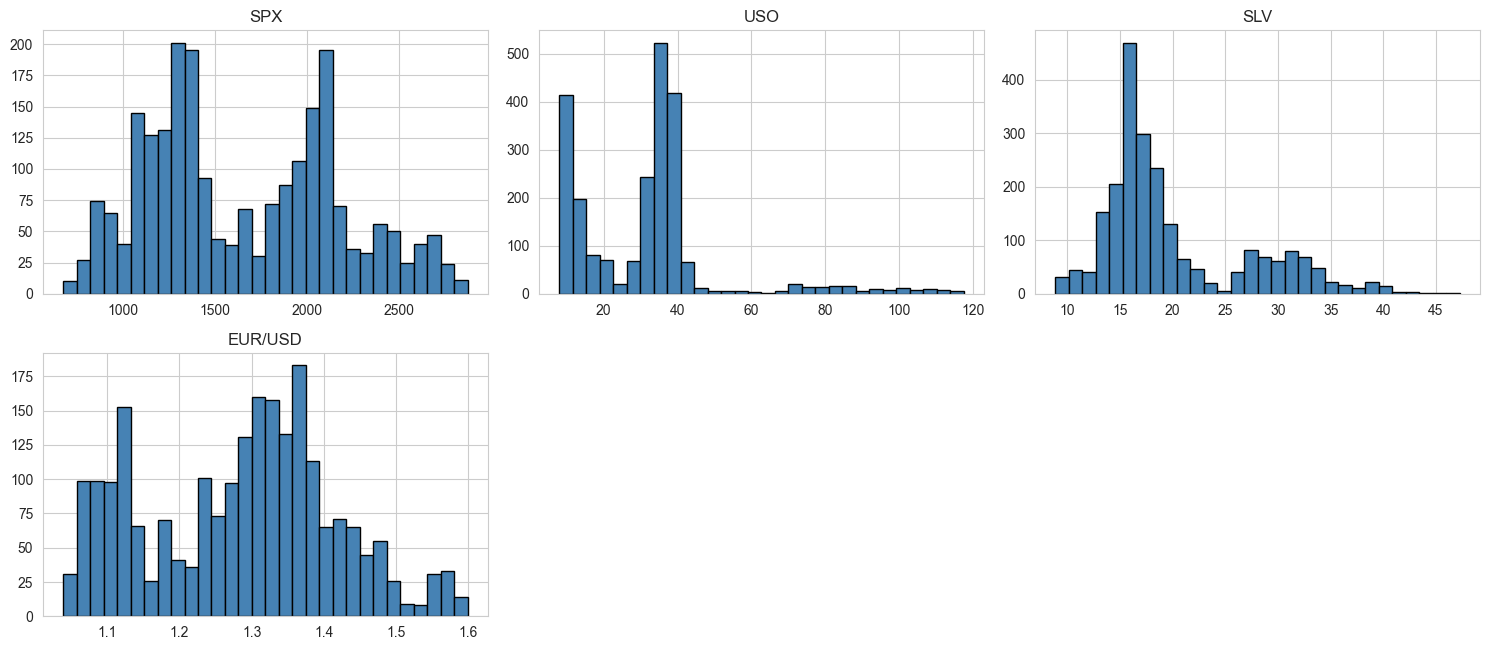

In [11]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

In [12]:
corrs_all = df[numeric_cols + ['GLD']].corr()['GLD'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'GLD'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
SLV        0.867
USO        0.186
SPX        0.049
EUR/USD    0.024
Name: GLD, dtype: float64


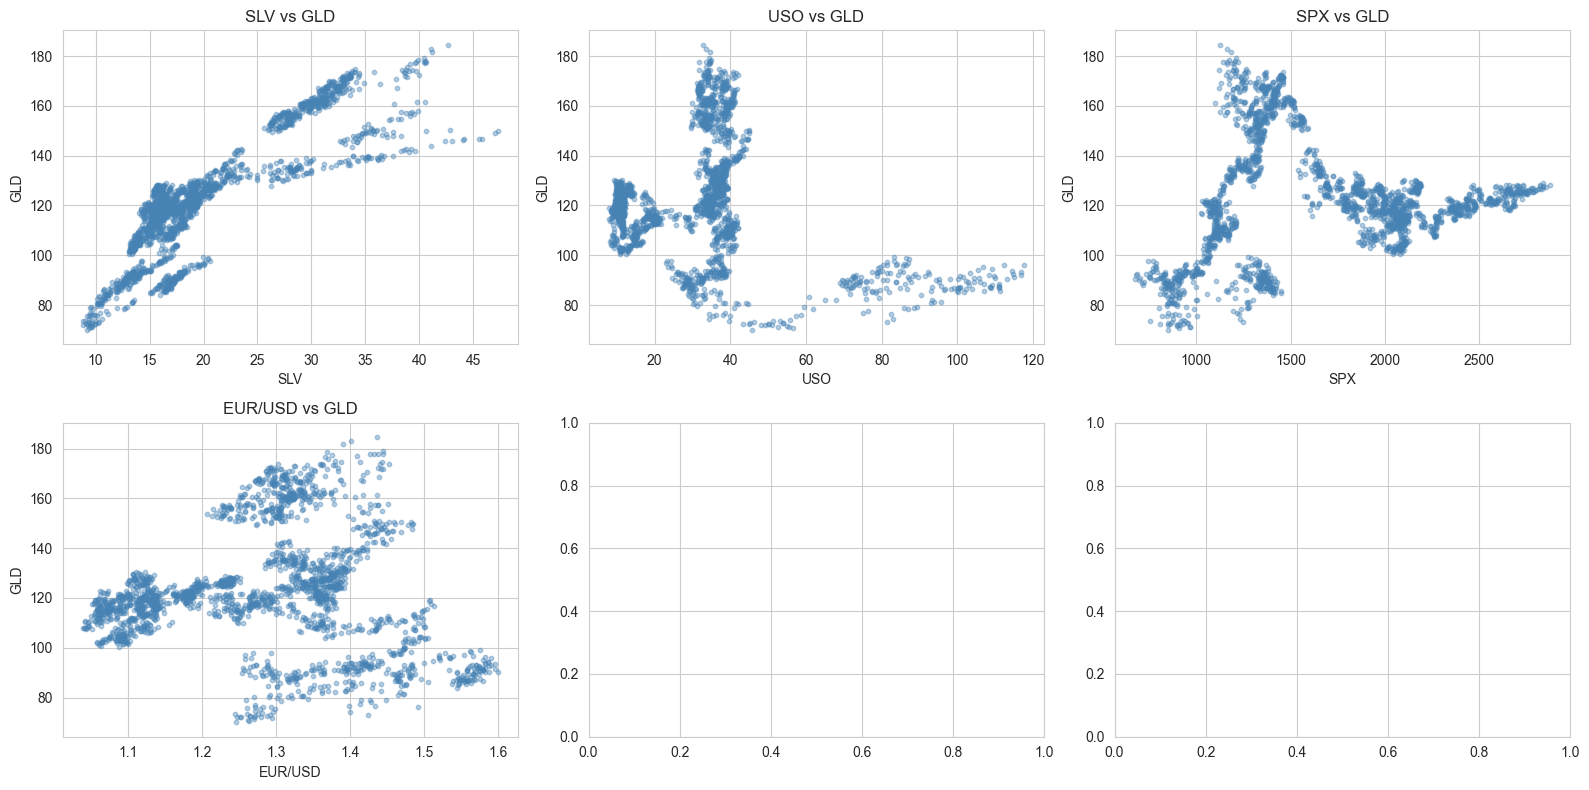

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top_features[:6]):
    axes[i].scatter(df[col], df['GLD'], alpha=0.4, s=10, color='steelblue')
    axes[i].set_xlabel(col); axes[i].set_ylabel('GLD')
    axes[i].set_title(f'{col} vs GLD')
plt.tight_layout(); plt.show()

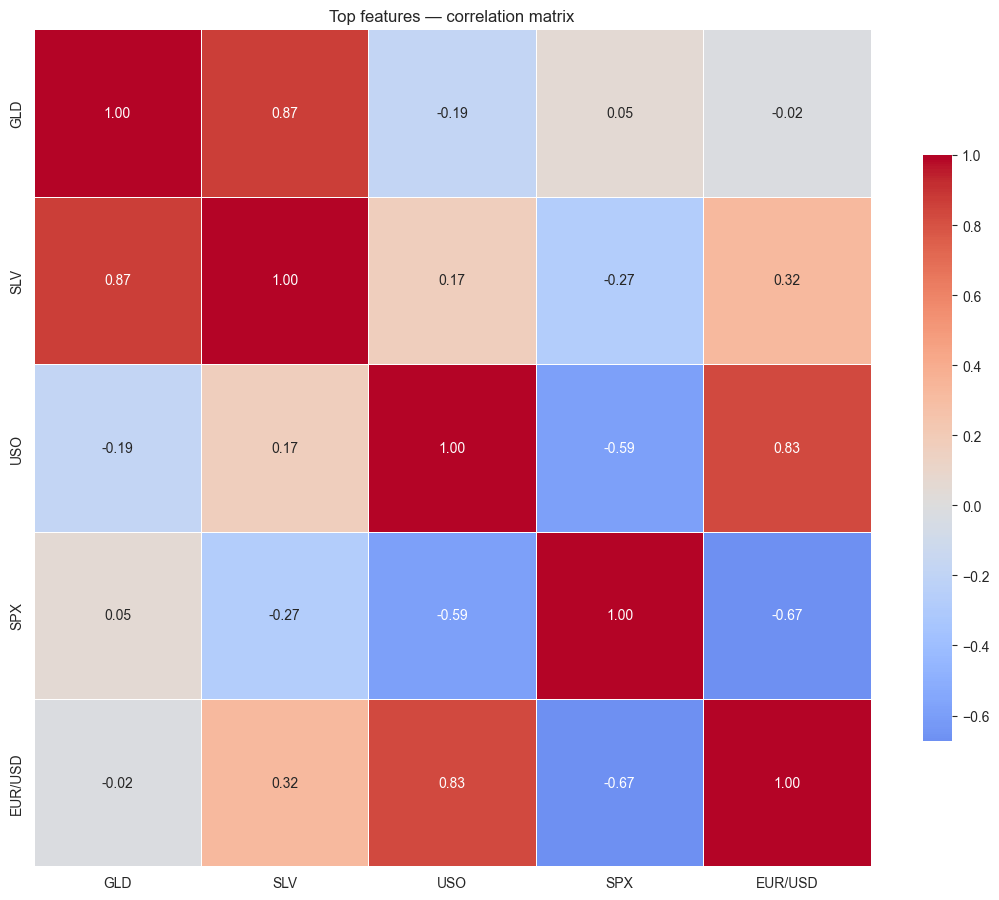

In [14]:
top_numeric = corrs_all.head(15).index.tolist()
if 'GLD' not in top_numeric:
    top_numeric.append('GLD')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

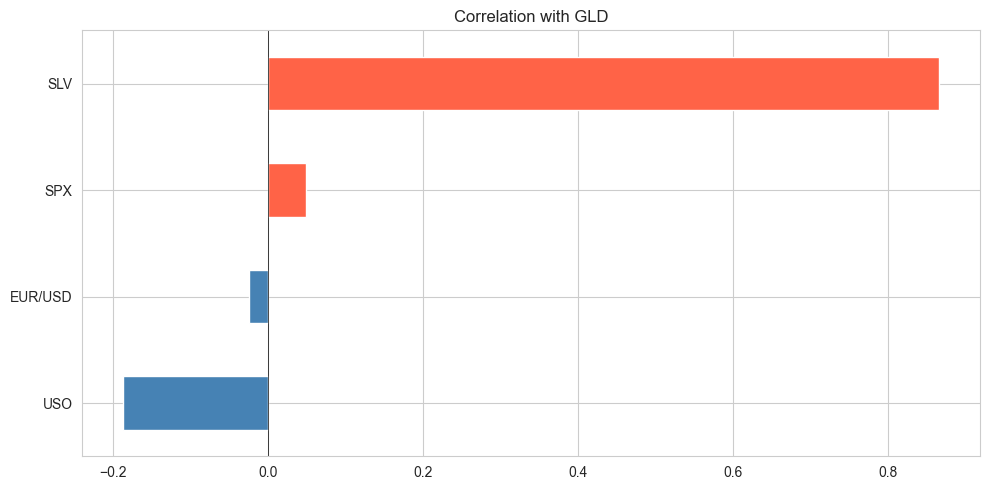

In [15]:
target_corr = df[numeric_cols + ['GLD']].corr()['GLD'].drop('GLD').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with GLD')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

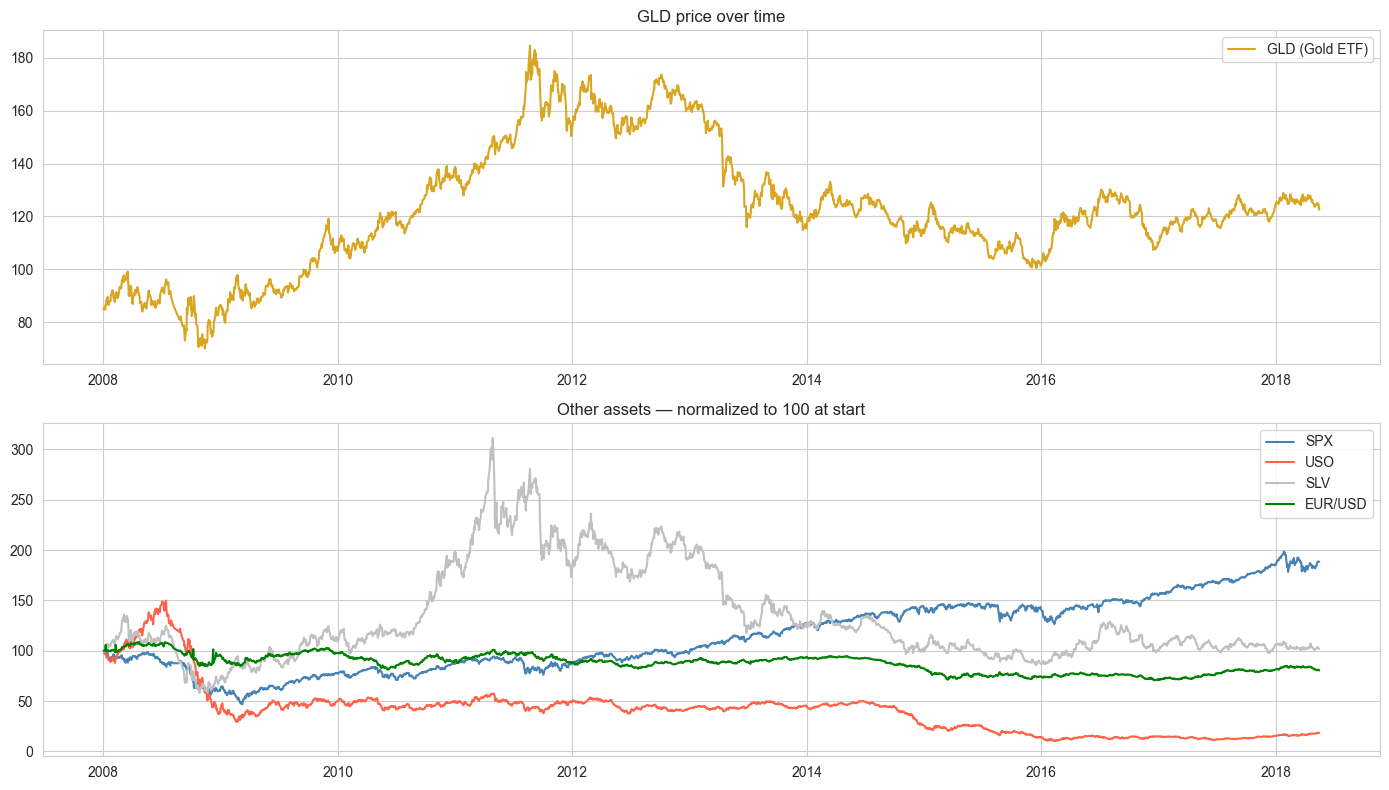

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df['Date'], df['GLD'], color='goldenrod', label='GLD (Gold ETF)')
axes[0].set_title('GLD price over time'); axes[0].legend()
for col, c in [('SPX', 'steelblue'), ('USO', 'tomato'), ('SLV', 'silver'), ('EUR/USD', 'green')]:
    if col in df.columns:
        axes[1].plot(df['Date'], df[col]/df[col].iloc[0]*100, label=col, color=c)
axes[1].set_title('Other assets — normalized to 100 at start')
axes[1].legend(); plt.tight_layout(); plt.show()

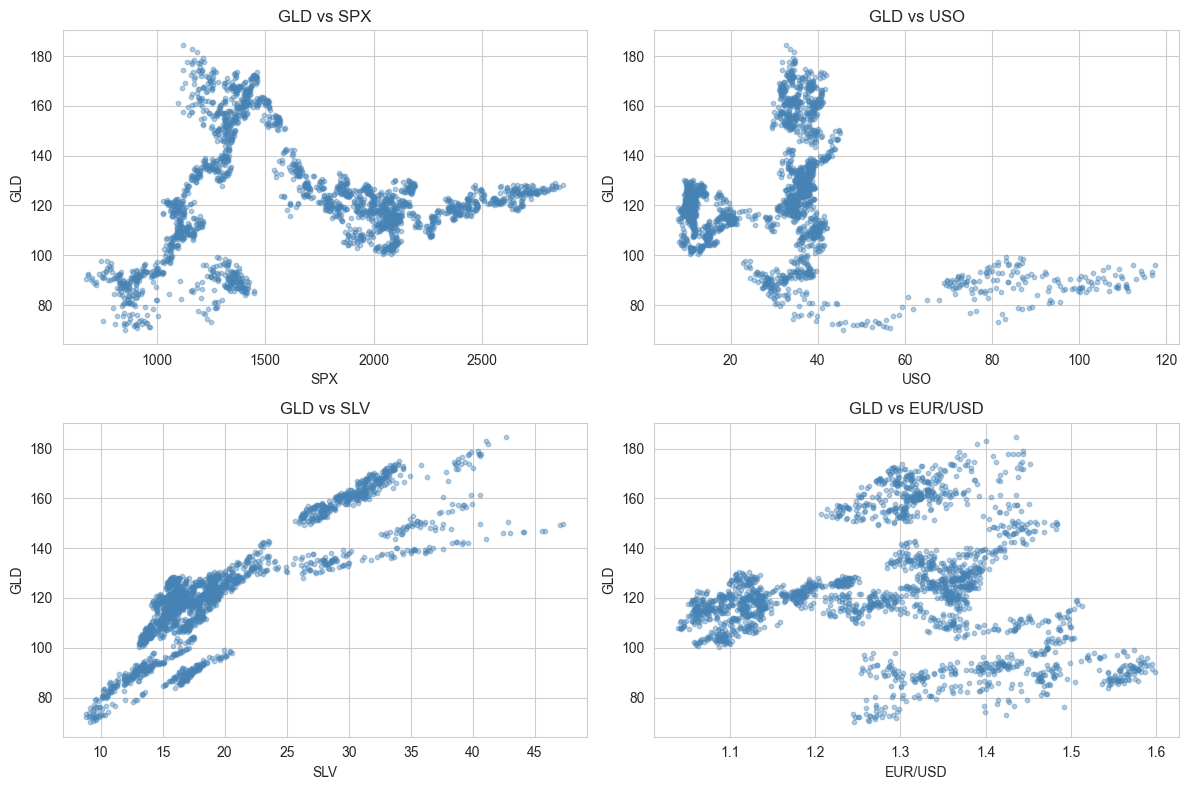

In [17]:
# Scatter: GLD vs each other asset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, ['SPX', 'USO', 'SLV', 'EUR/USD']):
    if col in df.columns:
        ax.scatter(df[col], df['GLD'], alpha=0.4, s=10, color='steelblue')
        ax.set_xlabel(col); ax.set_ylabel('GLD')
        ax.set_title(f'GLD vs {col}')
plt.tight_layout(); plt.show()

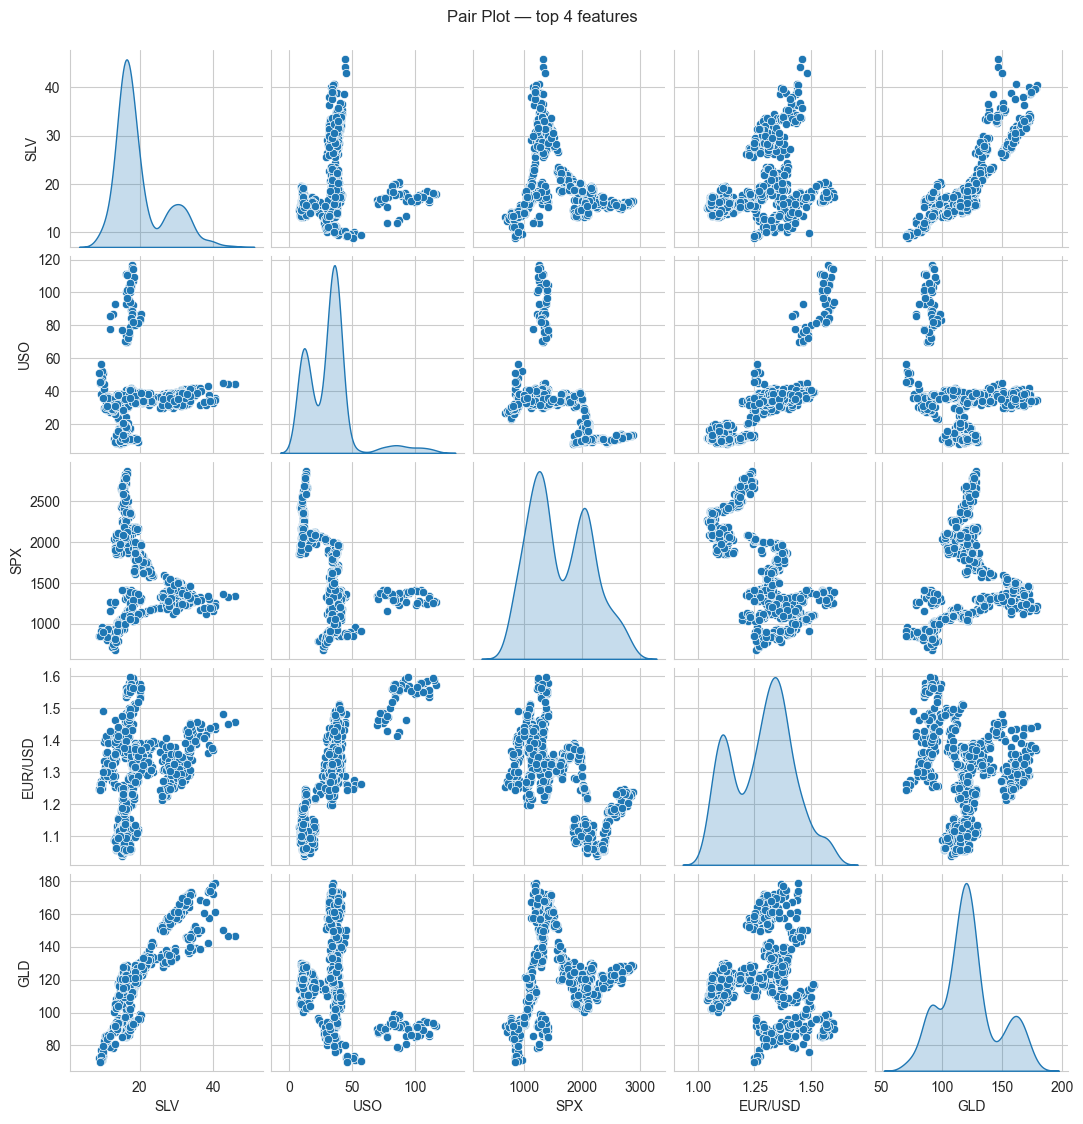

In [18]:
sample = df.sample(min(800, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['GLD']].dropna(), diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

In [19]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df['GLD'].mean(), 2),
        round(df['GLD'].median(), 2),
        round(df['GLD'].std(), 2),
        round(df['GLD'].min(), 2),
        round(df['GLD'].max(), 2),
        round(df['GLD'].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,2290
1,Total features,5
2,Target mean,122.73
3,Target median,120.58
4,Target stddev,23.28
5,Target min,70.0
6,Target max,184.59
7,Target skewness,0.334
8,Top correlated feature,SLV
9,Top correlation value,0.867


In [20]:
print('Missing values:', df.isnull().sum().sum())
print('Date range:', df['Date'].min(), '->', df['Date'].max())
df_clean = df.copy()

Missing values: 0
Date range: 2008-01-02 00:00:00 -> 2018-05-16 00:00:00


In [21]:
df_imputed = df_clean.copy()
print('NaN count:', df_imputed.isnull().sum().sum())

NaN count: 0


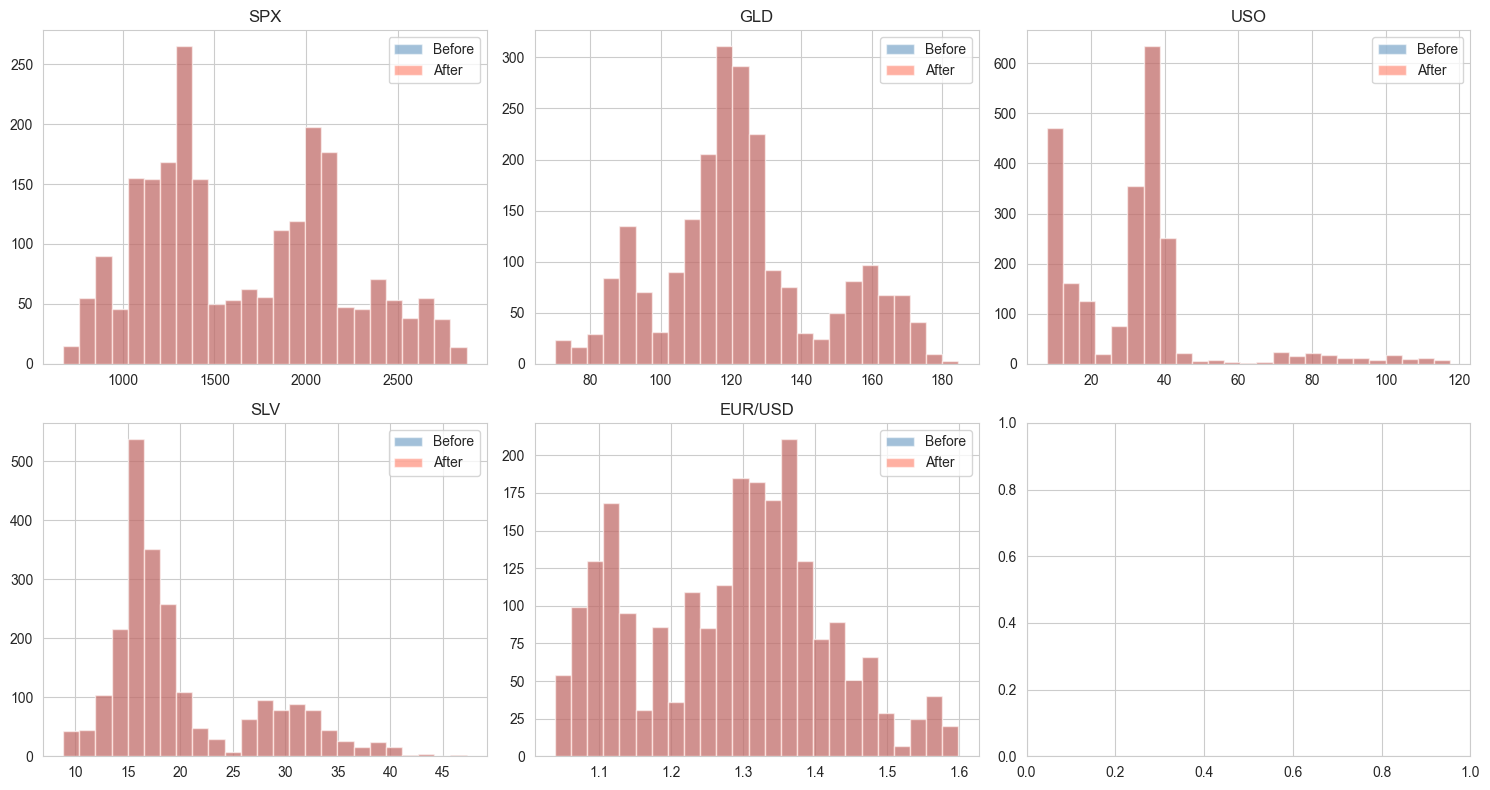

In [22]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [25]:
def create_features(df):
    """Engineer rolling means, diffs, and date-based features."""
    df = df.copy()

    if "Date" in df.columns:
        df["Year"] = df["Date"].dt.year
        df["Month"] = df["Date"].dt.month
        df["DayOfWeek"] = df["Date"].dt.dayofweek

    for col in ["SPX", "USO", "SLV", "EUR/USD"]:
        if col in df.columns:
            df[f"{col}_roll5"] = df[col].rolling(5, min_periods=1).mean()
            df[f"{col}_diff"] = df[col].diff().fillna(0)

    # Spread of related precious-metal / oil ETFs
    if {"SLV", "USO"}.issubset(df.columns):
        df["SLV_USO_ratio"] = df["SLV"] / df["USO"].replace(0, np.nan)

    # Drop the date column (replaced by year/month/dow)
    if "Date" in df.columns:
        df = df.drop(columns=["Date"])

    df = df.fillna(method="bfill").fillna(0)
    return df

In [26]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (2290, 17)


,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1447.160034,84.860001,78.470001,15.180,1.471692,2008,1,2,1447.160034,0.000000,78.470001,0.000000,15.180000,0.000,1.471692,0.000000,0.193450
1,1447.160034,85.570000,78.370003,15.285,1.474491,2008,1,3,1447.160034,0.000000,78.420002,-0.099998,15.232500,0.105,1.473091,0.002799,0.195036
2,1411.630005,85.129997,77.309998,15.167,1.475492,2008,1,4,1435.316691,-35.530029,78.050001,-1.060005,15.210667,-0.118,1.473892,0.001001,0.196184
3,1416.180054,84.769997,75.500000,15.053,1.468299,2008,1,0,1430.532532,4.550049,77.412500,-1.809998,15.171250,-0.114,1.472494,-0.007193,0.199377
4,1390.189941,86.779999,76.059998,15.590,1.557099,2008,1,1,1422.464014,-25.990113,77.142000,0.559998,15.255000,0.537,1.489415,0.088800,0.204970


In [27]:
def preprocess_data(df):
    df = create_features(df)
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(int)
    return df

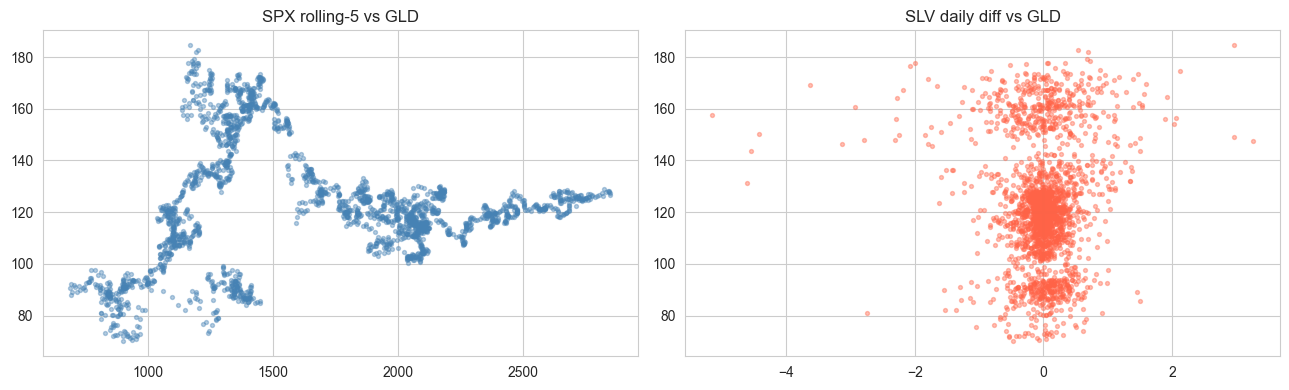

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if 'SPX_roll5' in df_feat.columns:
    axes[0].scatter(df_feat['SPX_roll5'], df_feat['GLD'], alpha=0.4, s=8, color='steelblue')
    axes[0].set_title('SPX rolling-5 vs GLD')
if 'SLV_diff' in df_feat.columns:
    axes[1].scatter(df_feat['SLV_diff'], df_feat['GLD'], alpha=0.4, s=8, color='tomato')
    axes[1].set_title('SLV daily diff vs GLD')
plt.tight_layout(); plt.show()

In [29]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Final shape:', df_encoded.shape)

Categorical columns: []
Final shape: (2290, 17)


In [31]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv(r"C:\Users\aadam\Desktop\Algorithmic Trading\Gold_Prediction\gold_price_data.csv", index=False)
print('Saved -> data/gold_price_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (2290, 17)
Saved -> data/gold_price_cleaned.csv


,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1447.160034,84.860001,78.470001,15.180,1.471692,2008,1,2,1447.160034,0.000000,78.470001,0.000000,15.180000,0.000,1.471692,0.000000,0.193450
1,1447.160034,85.570000,78.370003,15.285,1.474491,2008,1,3,1447.160034,0.000000,78.420002,-0.099998,15.232500,0.105,1.473091,0.002799,0.195036
2,1411.630005,85.129997,77.309998,15.167,1.475492,2008,1,4,1435.316691,-35.530029,78.050001,-1.060005,15.210667,-0.118,1.473892,0.001001,0.196184
3,1416.180054,84.769997,75.500000,15.053,1.468299,2008,1,0,1430.532532,4.550049,77.412500,-1.809998,15.171250,-0.114,1.472494,-0.007193,0.199377
4,1390.189941,86.779999,76.059998,15.590,1.557099,2008,1,1,1422.464014,-25.990113,77.142000,0.559998,15.255000,0.537,1.489415,0.088800,0.204970


In [32]:
def evaluate_model(model_name, y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    metrics = {
        "Model": model_name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse,
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(mean_absolute_percentage_error(y_true, y_pred)),
    }
    print(f"\n{'='*40}\n  {model_name}\n{'='*40}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k:6s}: {v:.4f}")
    return metrics

In [33]:
def plot_pred_vs_actual(y_true, y_pred, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, color="steelblue")
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.plot([lo, hi], [lo, hi], "r--", label="perfect")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(f"Predicted vs Actual — {model_name}"); ax.legend()
    return ax

In [34]:
def plot_residuals(y_true, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    residuals = np.array(y_true) - np.array(y_pred)
    axes[0].scatter(y_pred, residuals, alpha=0.4, s=15, color="steelblue")
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
    axes[0].set_title(f"Residuals vs Predicted — {model_name}")
    axes[1].hist(residuals, bins=40, color="seagreen", edgecolor="black")
    axes[1].set_xlabel("Residual"); axes[1].set_title("Residual distribution")
    plt.tight_layout()
    return fig

In [35]:
def cross_validate_model(model, X, y, cv=5):
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    print(f"  CV R² Scores : {scores.round(4)}")
    print(f"  Mean R²      : {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores

In [36]:
def compare_models(results_list):
    df_results = pd.DataFrame(results_list)
    return df_results.sort_values("R2", ascending=False).reset_index(drop=True)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [41]:
df = pd.read_csv(r"C:\Users\aadam\Desktop\Algorithmic Trading\Gold_Prediction\gold_price_data.csv")
print('Shape:', df.shape)
df.head()

Shape: (2290, 17)


,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1447.160034,84.860001,78.470001,15.180,1.471692,2008,1,2,1447.160034,0.000000,78.470001,0.000000,15.180000,0.000,1.471692,0.000000,0.193450
1,1447.160034,85.570000,78.370003,15.285,1.474491,2008,1,3,1447.160034,0.000000,78.420002,-0.099998,15.232500,0.105,1.473091,0.002799,0.195036
2,1411.630005,85.129997,77.309998,15.167,1.475492,2008,1,4,1435.316691,-35.530029,78.050001,-1.060005,15.210667,-0.118,1.473892,0.001001,0.196184
3,1416.180054,84.769997,75.500000,15.053,1.468299,2008,1,0,1430.532532,4.550049,77.412500,-1.809998,15.171250,-0.114,1.472493,-0.007193,0.199377
4,1390.189941,86.779999,76.059998,15.590,1.557099,2008,1,1,1422.464014,-25.990113,77.142000,0.559998,15.255000,0.537,1.489415,0.088800,0.204970


In [42]:
X = df.drop(columns=['GLD'])
y = df['GLD']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 16
Target stats:
count    2290.00
mean      122.73
std        23.28
min        70.00
25%       109.73
50%       120.58
75%       132.84
max       184.59
Name: GLD, dtype: float64
Train: (1832, 16) Test: (458, 16)


In [43]:
results = []
models = {}

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import cross_val_score


  Linear Regression
  MAE   : 5.0730
  RMSE  : 6.4875
  R2    : 0.9232
  MAPE  : 0.0415


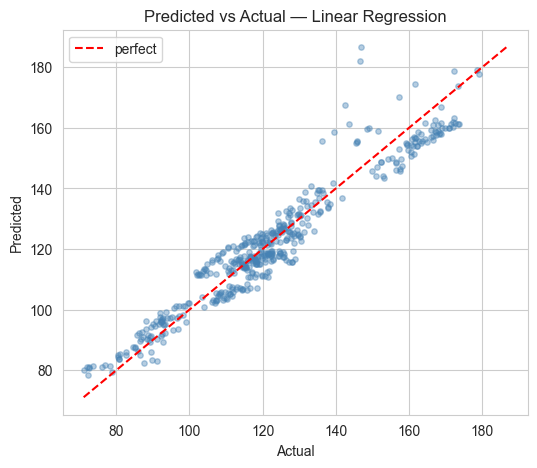

In [46]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()


  Ridge
  MAE   : 5.0550
  RMSE  : 6.4910
  R2    : 0.9232
  MAPE  : 0.0413


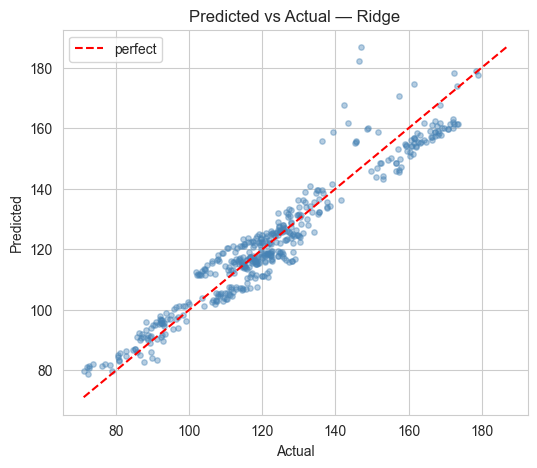

In [47]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()


  Lasso
  MAE   : 4.9476
  RMSE  : 6.5368
  R2    : 0.9221
  MAPE  : 0.0400


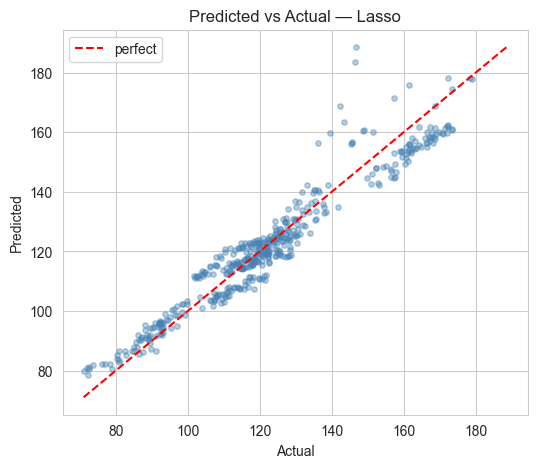

In [48]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()


  Decision Tree
  MAE   : 1.5143
  RMSE  : 2.2015
  R2    : 0.9912
  MAPE  : 0.0127


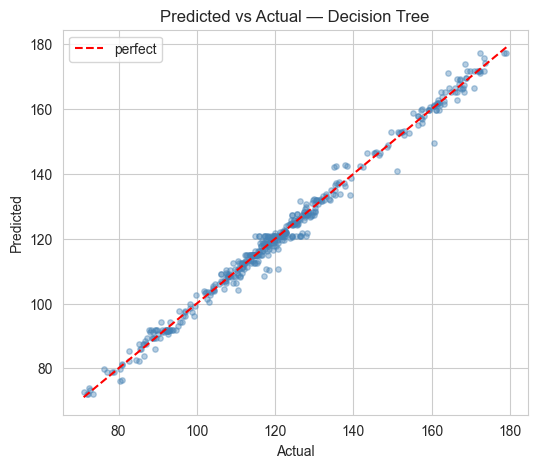

In [49]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()


  Random Forest
  MAE   : 1.0359
  RMSE  : 1.5936
  R2    : 0.9954
  MAPE  : 0.0086


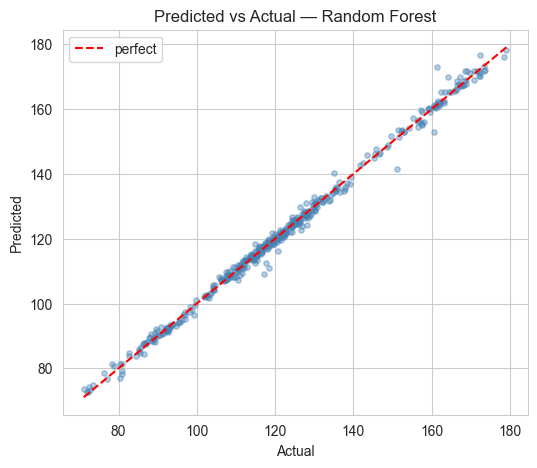

In [53]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()

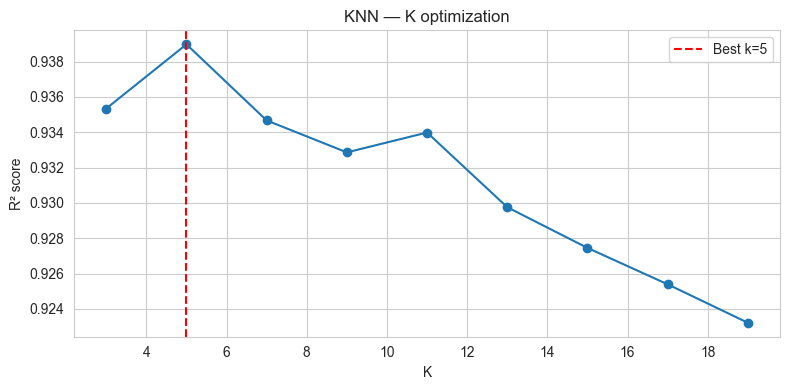


  KNN (k=5)
  MAE   : 3.7909
  RMSE  : 5.7846
  R2    : 0.9390
  MAPE  : 0.0314


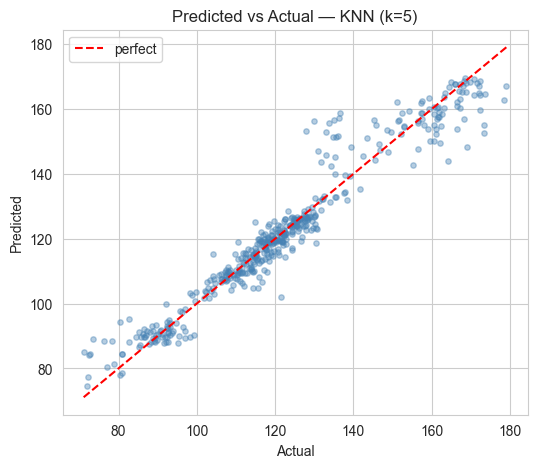

In [54]:
k_range = range(3, 21, 2)
from sklearn.metrics import r2_score
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4)); plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, knn_label); plt.show()


  Gradient Boosting
  MAE   : 1.4849
  RMSE  : 2.1137
  R2    : 0.9919
  MAPE  : 0.0122


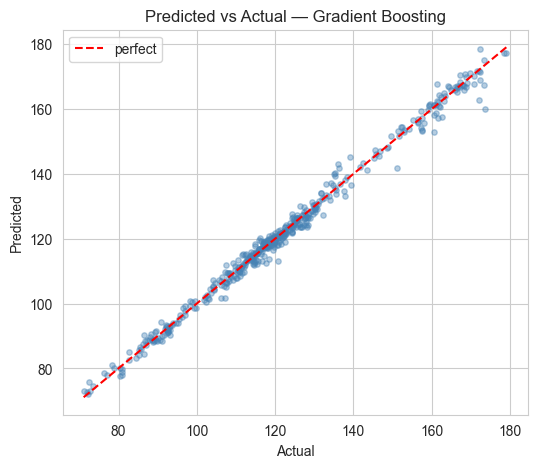

In [55]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting'); plt.show()

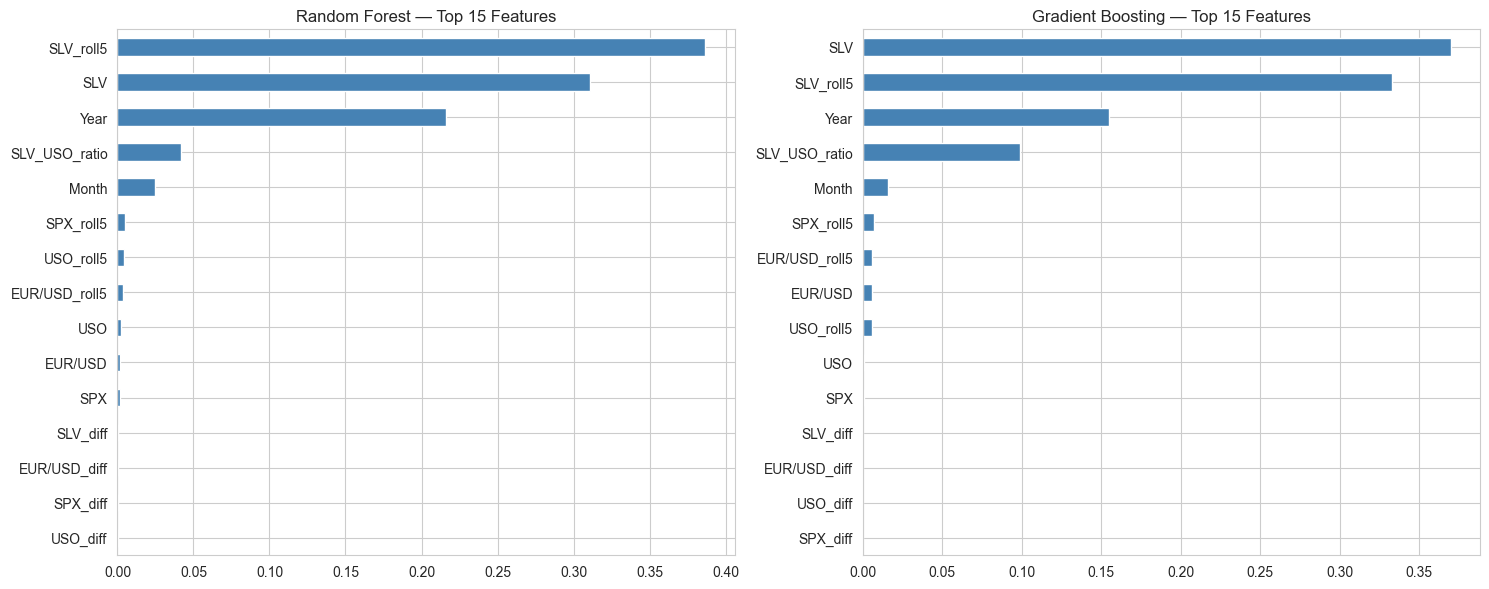

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()

In [57]:
comparison = compare_models(results)
comparison

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,1.035867,1.593620,0.995368,0.008625
1,Random Forest,1.035867,1.593620,0.995368,0.008625
2,Random Forest,1.035867,1.593620,0.995368,0.008625
3,Gradient Boosting,1.484905,2.113703,0.991852,0.012211
4,Decision Tree,1.514266,2.201466,0.991161,0.012714
5,KNN (k=5),3.790866,5.784589,0.938972,0.031399
6,Linear Regression,5.073017,6.487530,0.923239,0.041487
7,Ridge,5.054986,6.491013,0.923157,0.041283
8,Lasso,4.947573,6.536762,0.922070,0.040005


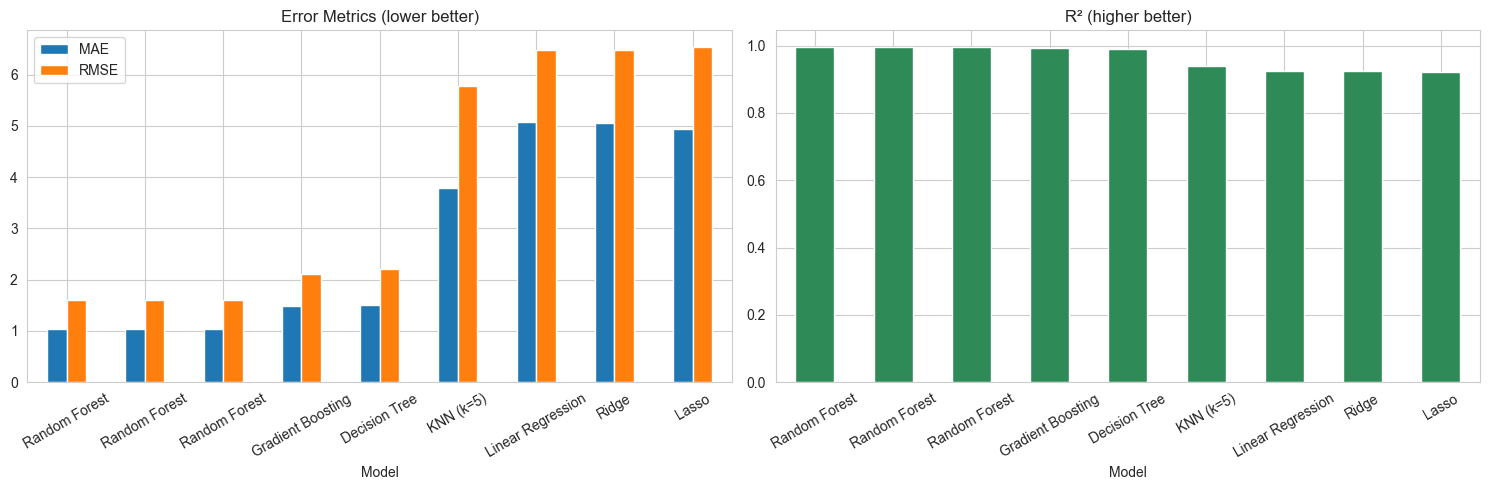

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

In [59]:
cv_scores = {}
X_full_scaled = scaler.fit_transform(X)
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='r2', n_jobs=-1)
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear Regression         mean R² = -0.4711 (+/- 1.6337)
Ridge                     mean R² = -0.4239 (+/- 1.5431)
Lasso                     mean R² = -0.0465 (+/- 0.6592)
Decision Tree             mean R² = -0.3938 (+/- 1.2400)
Random Forest             mean R² = -0.2228 (+/- 1.2952)
KNN (k=5)                 mean R² = -1.5146 (+/- 2.3986)
Gradient Boosting         mean R² = -0.1744 (+/- 1.2269)


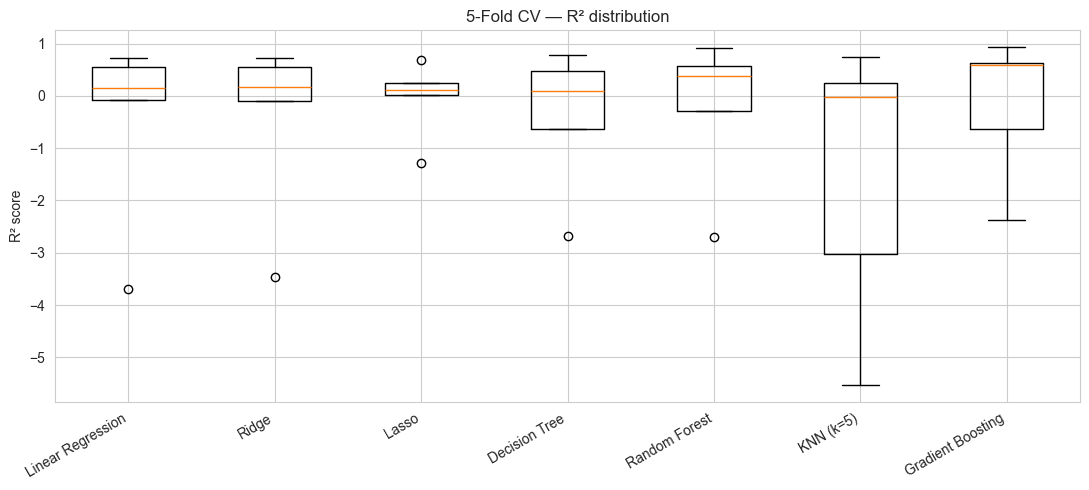

In [60]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('5-Fold CV — R² distribution'); plt.tight_layout(); plt.show()

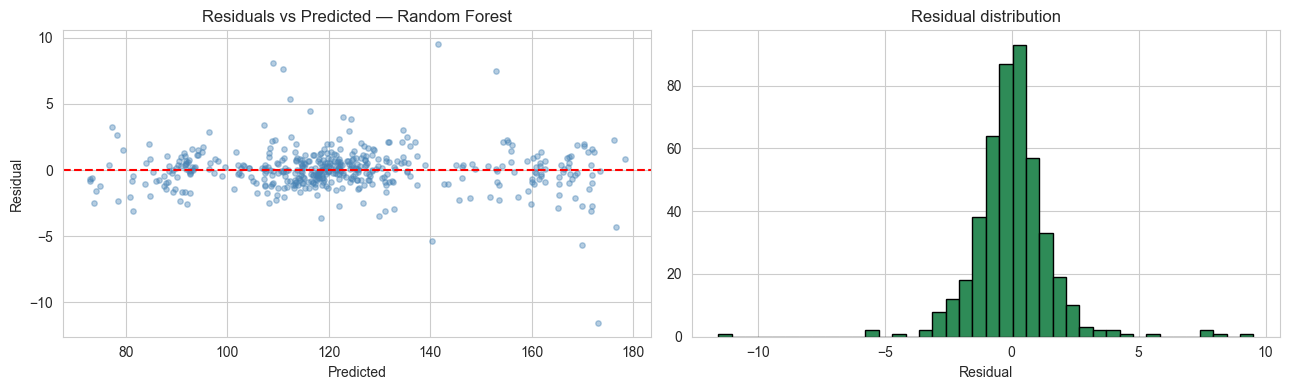

In [61]:
best_model_name = comparison.iloc[0]['Model']
kind, best_pre = models[best_model_name]
Xt = X_test_scaled if kind == 'scaled' else X_test
y_pred_best = best_pre.predict(Xt)
plot_residuals(y_test, y_pred_best, best_model_name); plt.show()

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV R²: 0.9925

  Random Forest (Tuned)
  MAE   : 1.0301
  RMSE  : 1.5810
  R2    : 0.9954
  MAPE  : 0.0086


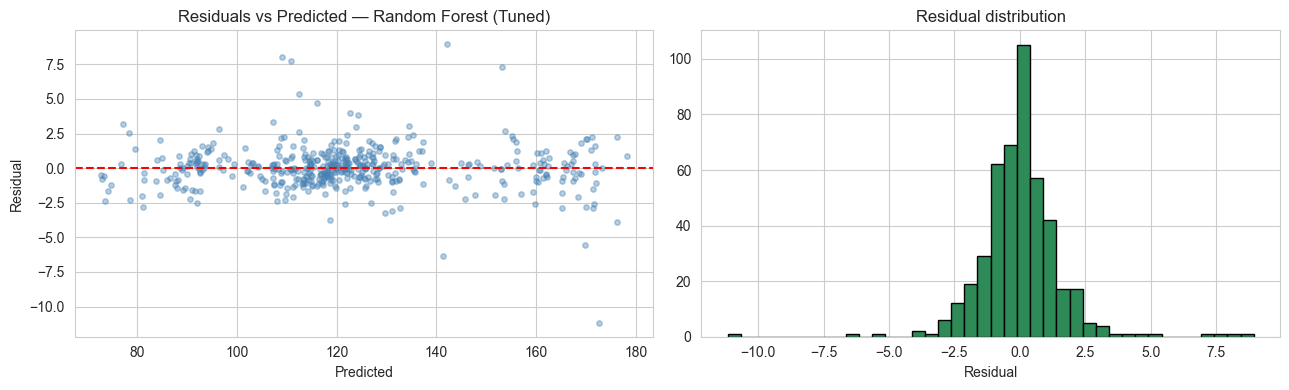

In [63]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
}
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Random Forest (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Random Forest (Tuned)'); plt.show()

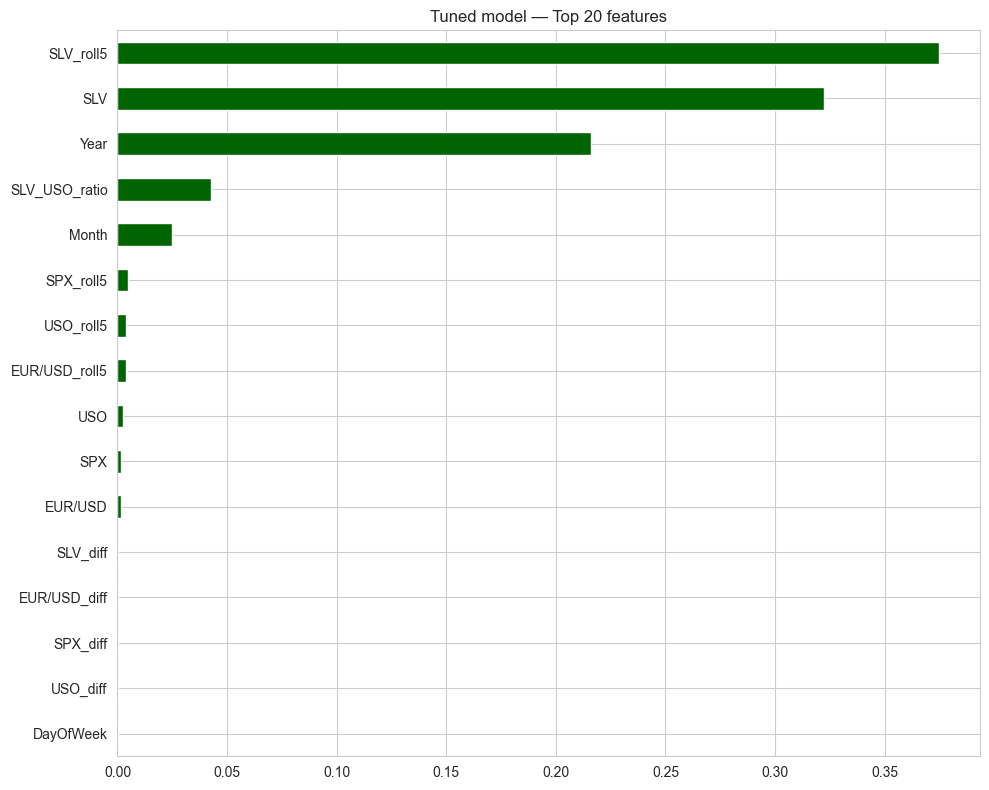

In [64]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()

In [65]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out

,Predicted,Actual,AbsError
0,122.38,122.32,0.06
1,129.57,129.90,0.33
2,127.75,126.98,0.77
3,96.45,96.50,0.05
4,118.01,117.58,0.43


In [66]:
final = compare_models(results)
final

,Model,MAE,RMSE,R2,MAPE
0,Random Forest (Tuned),1.030113,1.581043,0.995441,0.008569
1,Random Forest,1.035867,1.593620,0.995368,0.008625
2,Random Forest,1.035867,1.593620,0.995368,0.008625
3,Random Forest,1.035867,1.593620,0.995368,0.008625
4,Gradient Boosting,1.484905,2.113703,0.991852,0.012211
5,Decision Tree,1.514266,2.201466,0.991161,0.012714
6,KNN (k=5),3.790866,5.784589,0.938972,0.031399
7,Linear Regression,5.073017,6.487530,0.923239,0.041487
8,Ridge,5.054986,6.491013,0.923157,0.041283
9,Lasso,4.947573,6.536762,0.922070,0.040005
